<a href="https://colab.research.google.com/github/mvgolubev99/kaggle-chemical-structure-and-logp/blob/dev/interaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# run these cells in google colab

In [ ]:
# clone repo
!git clone https://github.com/mvgolubev99/kaggle-chemical-structure-and-logp.git

In [21]:
# cd to project directory
!pwd
%cd /content/kaggle-chemical-structure-and-logp/
!pwd
!ls

/content/kaggle-chemical-structure-and-logp
/content/kaggle-chemical-structure-and-logp
README.md


In [42]:
# checkout to branch if neccesary
!git checkout dev

A	configs/default_lgbm_all_fingerprints.yaml
A	configs/default_ridge_all_fingerprints.yaml
Already on 'dev'
Your branch is up to date with 'origin/dev'.


In [23]:
# install packages
!pip install rdkit optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 36.2 MB/s eta 0:00:00


# Interaction

In [27]:
# download data
!mkdir -p ./data; curl -L -o ./data/archive_logp.zip https://www.kaggle.com/api/v1/datasets/download/matthewmasters/chemical-structure-and-logp; unzip ./data/archive_logp.zip -d ./data/; rm ./data/archive_logp.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 81468  100 81468    0     0   134k      0 --:--:-- --:--:-- --:--:--  134k
Archive:  ./data/archive_logp.zip
  inflating: ./data/logP_dataset.csv  


In [29]:
# generate fingerprints
!python fingerprints.py

Converting data from smiles to all fingerprints...

saving fingerprints to folder: 'data'

[1/7]
fp_name=MorganFingerprint_2048 
fingerprints saved as 'data/MorganFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[2/7]
fp_name=FeaturesMorganFingerprint_2048 
fingerprints saved as 'data/FeaturesMorganFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[3/7]
fp_name=MACCSKeysFingerprint_167 
fingerprints saved as 'data/MACCSKeysFingerprint_167_X_data.npy'
fps.shape=(14610, 167)
[4/7]
fp_name=RDKitFingerprint_2048 
fingerprints saved as 'data/RDKitFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[5/7]
fp_name=AtomPairFingerprint_2048 
fingerprints saved as 'data/AtomPairFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[6/7]
fp_name=TopologicalTorsionFingerprint_2048 
fingerprints saved as 'data/TopologicalTorsionFingerprint_2048_X_data.npy'
fps.shape=(14610, 2048)
[7/7]
fp_name=AvalonFingerprint_1024 
fingerprints saved as 'data/AvalonFingerprint_1024_X_data.npy'
fps.shape=(14

In [24]:
# FIX SEED!
from utils import set_seed
set_seed(42)

In [ ]:
#!rm -rf ./results

In [36]:
import warnings

from search_cv import run_experiment_search_cv

In [ ]:
# random search with different constants on dummy classifier for testing
exp = run_experiment_search_cv("./configs/dummy_config.yaml")

[I 2025-11-16 13:22:02,752] A new study created in memory with name: default_xgb_all_fingerprints
/usr/local/lib/python3.12/dist-packages/optuna/progress_bar.py:51: UserWarning: Progress bar won't be displayed because n_trials and timeout are None.
  warnings.warn("Progress bar won't be displayed because n_trials and timeout are None.")
[I 2025-11-16 13:22:10,928] Trial 0 finished with value: 0.346165581380614 and parameters: {'regressor__fp_transform__name': 'AvalonFingerprint_1024'}. Best is trial 0 with value: 0.346165581380614.
[I 2025-11-16 13:22:13,126] Trial 1 finished with value: 0.3170670159921186 and parameters: {'regressor__fp_transform__name': 'MACCSKeysFingerprint_167'}. Best is trial 1 with value: 0.3170670159921186.
[I 2025-11-16 13:22:29,288] Trial 2 finished with value: 0.7974092351788172 and parameters: {'regressor__fp_transform__name': 'FeaturesMorganFingerprint_2048'}. Best is trial 1 with value: 0.3170670159921186.
[I 2025-11-16 13:22:46,660] Trial 3 finished with 

best_on_val_bootstrap_score {'metric_name': 'root_mean_squared_error', 'score_mean': 0.3085315178960654, 'score_CI': [0.29411281123605715, 0.323193157279608]}


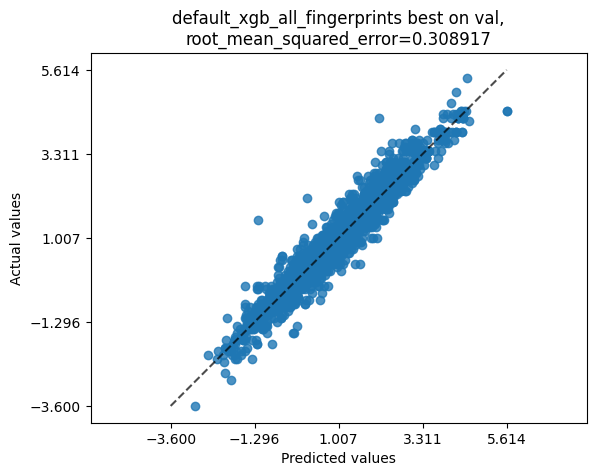

In [32]:
# grid search with ALL fingerprints on default xgbregressor
exp = run_experiment_search_cv("./configs/default_xgb_all_fingerprints.yaml")

[I 2025-11-16 13:32:15,605] A new study created in memory with name: default_lgbm_all_fingerprints
[I 2025-11-16 13:32:18,770] Trial 0 finished with value: 0.3480182167055582 and parameters: {'regressor__fp_transform__name': 'AvalonFingerprint_1024'}. Best is trial 0 with value: 0.3480182167055582.
[I 2025-11-16 13:32:19,887] Trial 1 finished with value: 0.3424944481879483 and parameters: {'regressor__fp_transform__name': 'MACCSKeysFingerprint_167'}. Best is trial 1 with value: 0.3424944481879483.
[I 2025-11-16 13:32:23,059] Trial 2 finished with value: 0.7995279853781863 and parameters: {'regressor__fp_transform__name': 'FeaturesMorganFingerprint_2048'}. Best is trial 1 with value: 0.3424944481879483.
[I 2025-11-16 13:32:28,934] Trial 3 finished with value: 0.43884741410548445 and parameters: {'regressor__fp_transform__name': 'RDKitFingerprint_2048'}. Best is trial 1 with value: 0.3424944481879483.
[I 2025-11-16 13:32:31,245] Trial 4 finished with value: 0.7995279853781863 and paramet

best_on_val_bootstrap_score {'metric_name': 'root_mean_squared_error', 'score_mean': 0.33507290680136453, 'score_CI': [0.32320486754344036, 0.3477127762420632]}


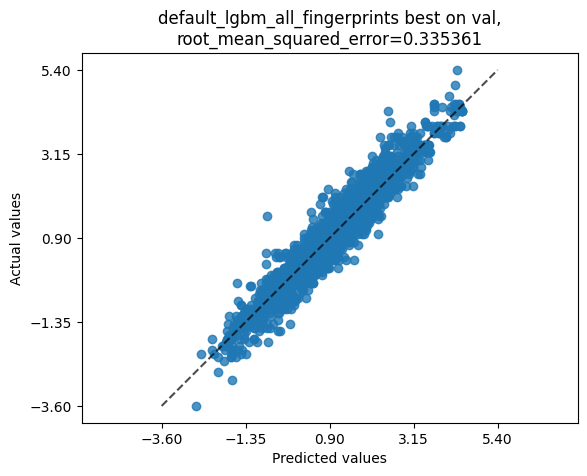

In [37]:
with warnings.catch_warnings():
    # lgbm creates column names for features
    # even though no arrays or dataframes are passed as arguments to .fit() method
    warnings.filterwarnings("ignore", category=UserWarning)

    # grid search with ALL fingerprints on default lgbm
    exp = run_experiment_search_cv("./configs/default_lgbm_all_fingerprints.yaml")

[I 2025-11-16 13:46:26,777] A new study created in memory with name: default_ridge_all_fingerprints
/usr/local/lib/python3.12/dist-packages/optuna/progress_bar.py:51: UserWarning: Progress bar won't be displayed because n_trials and timeout are None.
  warnings.warn("Progress bar won't be displayed because n_trials and timeout are None.")
[I 2025-11-16 13:46:29,358] Trial 0 finished with value: 0.47878251780669145 and parameters: {'regressor__fp_transform__name': 'AvalonFingerprint_1024'}. Best is trial 0 with value: 0.47878251780669145.
[I 2025-11-16 13:46:29,682] Trial 1 finished with value: 0.4595572113132854 and parameters: {'regressor__fp_transform__name': 'MACCSKeysFingerprint_167'}. Best is trial 1 with value: 0.4595572113132854.
[I 2025-11-16 13:46:38,733] Trial 2 finished with value: 0.8106112175924297 and parameters: {'regressor__fp_transform__name': 'FeaturesMorganFingerprint_2048'}. Best is trial 1 with value: 0.4595572113132854.
[I 2025-11-16 13:46:46,018] Trial 3 finished

best_on_val_bootstrap_score {'metric_name': 'root_mean_squared_error', 'score_mean': 0.4597499937786107, 'score_CI': [0.4417814679684518, 0.4767017714127563]}


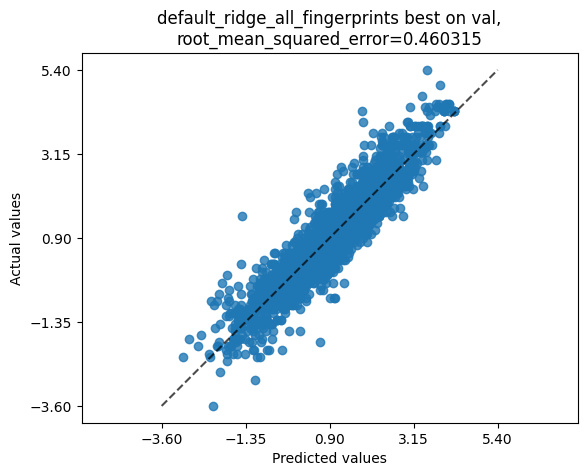

In [39]:
# grid search with ALL fingerprints on default ridge (linear regression with L2)
exp = run_experiment_search_cv("./configs/default_ridge_all_fingerprints.yaml")